In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('HR_Sailfort_dataset.csv')

In [3]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
df.tail()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


In [5]:
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
12216,0.36,0.48,2,158,3,0,1,0,IT,low
14304,0.46,0.55,2,129,3,0,1,0,sales,low
9272,0.95,0.51,3,254,4,0,0,0,technical,medium
12877,0.88,0.99,5,253,2,0,0,0,technical,medium
9487,0.62,0.78,5,250,6,0,0,0,sales,low


# Shape of Data Set
*Our data_set have 10 columns and  14999 rows*

In [6]:
df.shape

(14999, 10)

# Column Types
Numerical :- satisfaction_level , last_evaluation , number_of_projects , average_monthly_hours , tenure


Categorical :- Salary , Department




# all the values in all categories are non-nulls

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [8]:
df = df.rename(columns = {'number_project': 'number_of_projects',
                             'average_montly_hours': 'average_monthly_hours',
                             'Department': 'department',
                             'Work_accident': 'work_accident',
                             'time_spend_company': 'tenure'})

# Describing the numerical variables

In [9]:
df.drop(['work_accident', 'left', 'promotion_last_5years'], axis = 1).describe()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233
std,0.248631,0.171169,1.232592,49.943099,1.460136
min,0.090000,0.360000,2.000000,96.000000,2.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000


# Checking Categorical Variables

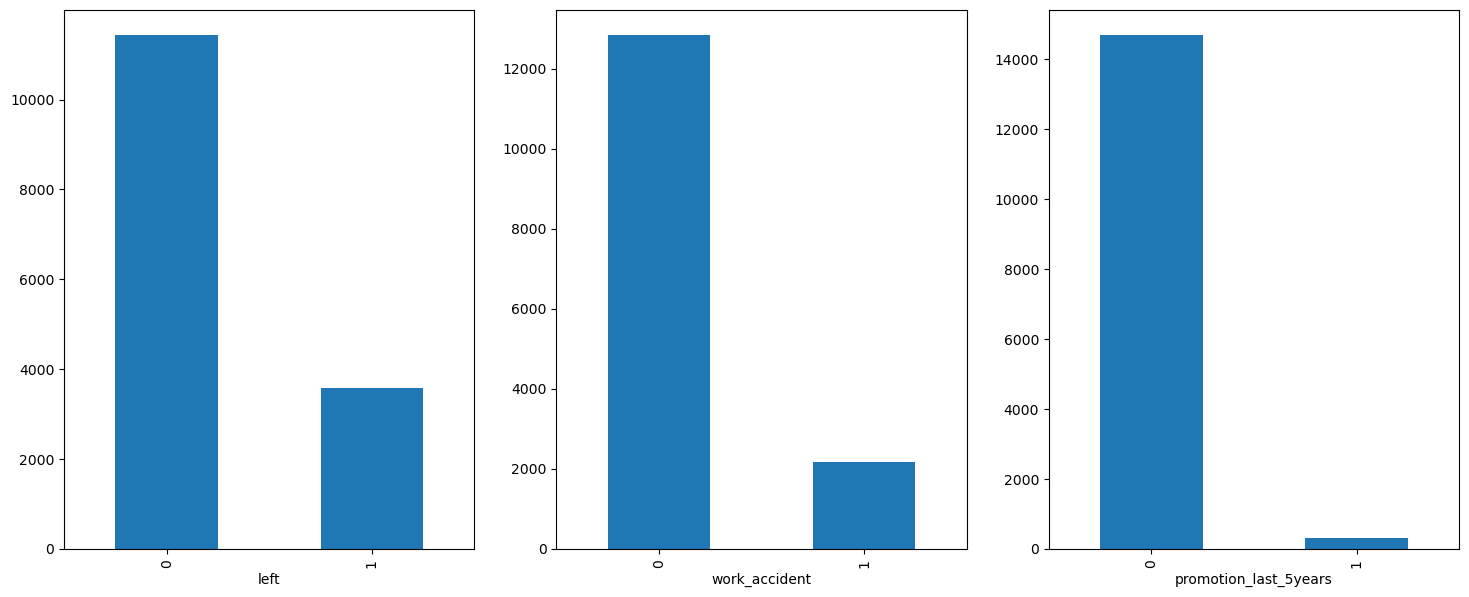

In [10]:
fig, ax = plt.subplots(1, 3, figsize = (18, 7))

df['left'].value_counts().plot.bar(ax = ax[0])
df['work_accident'].value_counts().plot.bar(ax = ax[1])
df['promotion_last_5years'].value_counts().plot.bar(ax = ax[2])

plt.show()

In [11]:
print("\n")

print("Categories in department variable :- ",np.unique(df['department'].values))

print("\n")

print("Categories in salary variable :- ",np.unique(df['salary'].values))

print("\n")



Categories in department variable :-  ['IT' 'RandD' 'accounting' 'hr' 'management' 'marketing' 'product_mng'
 'sales' 'support' 'technical']


Categories in salary variable :-  ['high' 'low' 'medium']




# Checking Duplicates

In [12]:
print("There are ",df.duplicated().sum(),"rows are duplicated in the data")

There are  3008 rows are duplicated in the data


# Conclusion on duplicated entries in our  data 
* from the first 10 duplicated values we seen that there is no column state that this values are collected from different employee thats why we decided to drop all the duplicates from the table 

In [13]:
df[df.duplicated()].head(10)

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [14]:
df=df.drop_duplicates(keep='first')

In [15]:
print("there are ",df.size," values left after dropping the all duplicated values")

there are  119910  values left after dropping the all duplicated values


# satisfaction_level
*Conclusion*

* data is negatively skew
* there is no outlier


  

<Axes: ylabel='number of employee'>

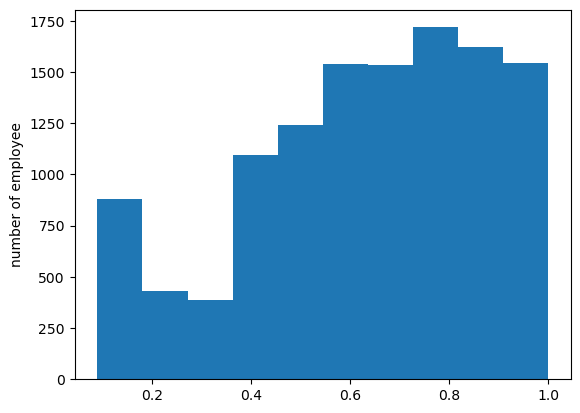

In [16]:
df['satisfaction_level'].plot(kind='hist',ylabel='number of employee')

<Axes: ylabel='Density'>

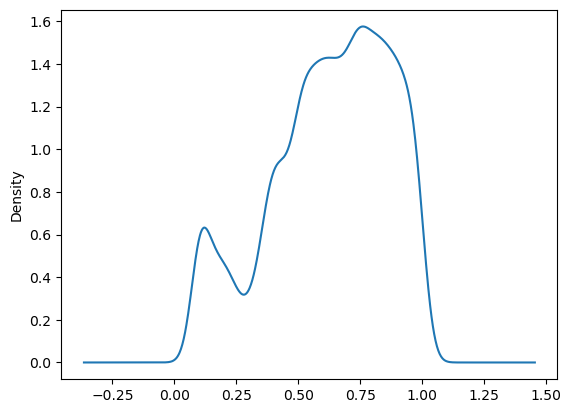

In [17]:
df['satisfaction_level'].plot(kind='kde')

In [18]:
df['satisfaction_level'].skew()

np.float64(-0.5387016649389459)

<Axes: >

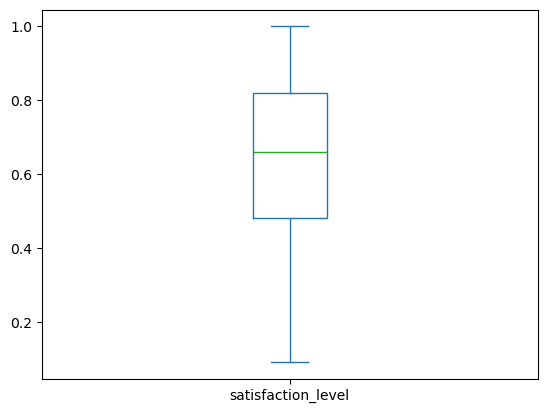

In [19]:
df['satisfaction_level'].plot(kind='box')

## last_evaluation
 Conclusion 
* Data is negatively skew
* there is no outlier

<Axes: ylabel='number of employee'>

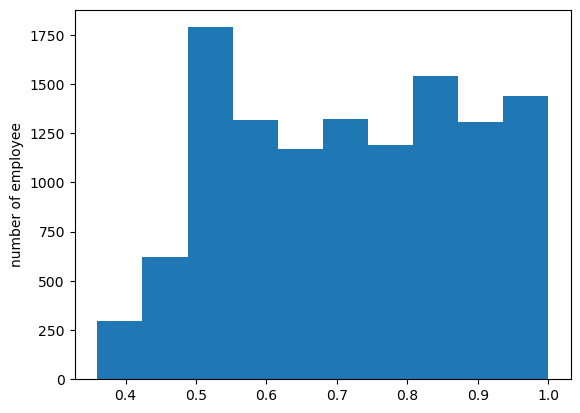

In [20]:

df['last_evaluation'].plot(kind='hist',ylabel='number of employee')

<Axes: ylabel='Density'>

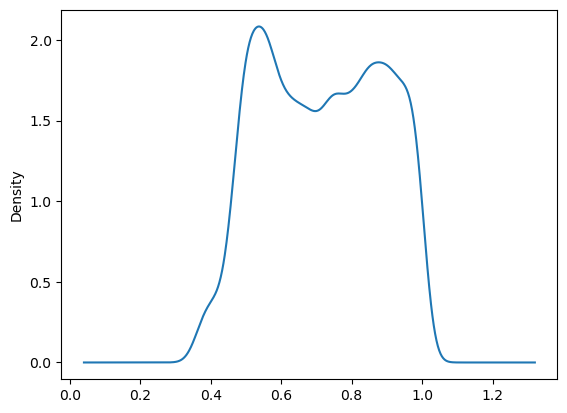

In [21]:
df['last_evaluation'].plot(kind='kde')

In [22]:
print(" data is skew by ",df['last_evaluation'].skew())

 data is skew by  -0.031686075200590205


<Axes: >

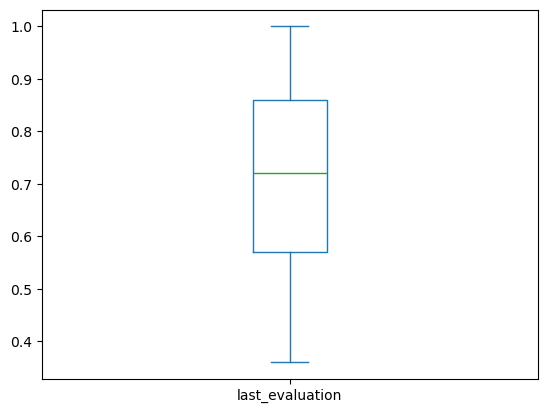

In [23]:
df['last_evaluation'].plot(kind='box')

<Axes: xlabel='number of projects', ylabel='number of employee'>

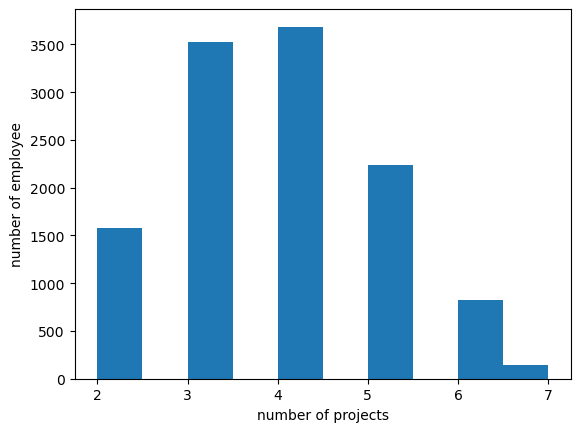

In [24]:
df['number_of_projects'].plot(kind='hist',ylabel='number of employee',xlabel='number of projects')

<Axes: >

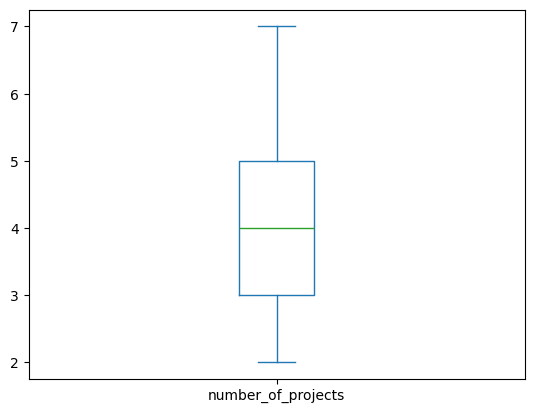

In [25]:
df['number_of_projects'].plot(kind='box')

<Axes: xlabel='average_monthly_hours', ylabel='number_of_employee'>

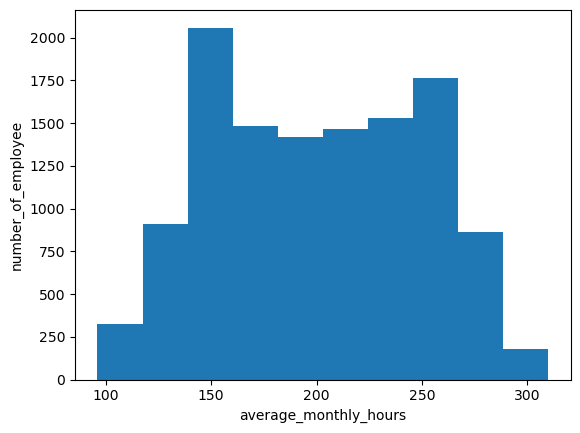

In [26]:
df['average_monthly_hours'].plot(kind='hist',xlabel='average_monthly_hours',ylabel='number_of_employee')

<Axes: ylabel='Density'>

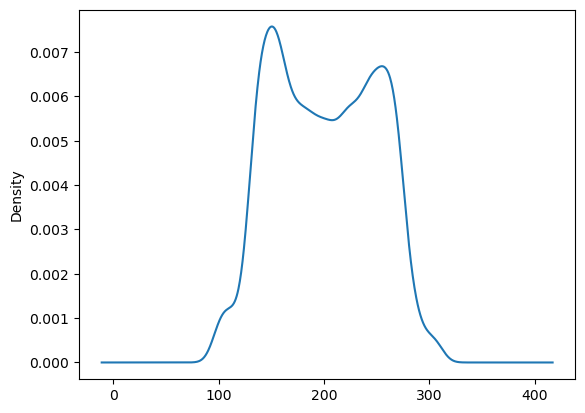

In [27]:
df['average_monthly_hours'].plot(kind='kde')

In [28]:
df['average_monthly_hours'].skew()

np.float64(0.02720803700294239)

<Axes: >

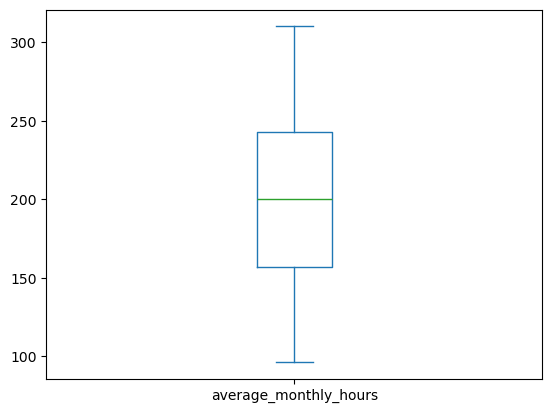

In [29]:
df['average_monthly_hours'].plot(kind='box')

## tenure
* data is having outliers
* data is slightly positively skew

<Axes: ylabel='Frequency'>

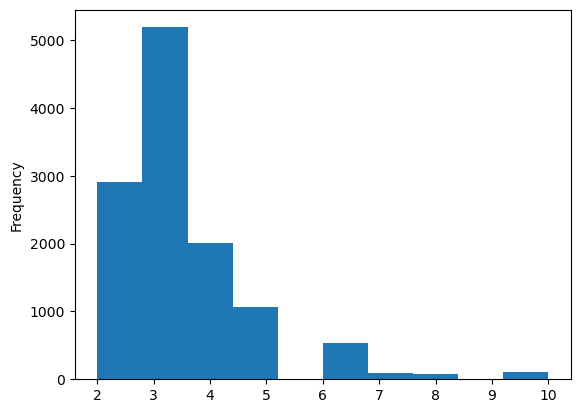

In [30]:
df['tenure'].plot(kind='hist')

<Axes: >

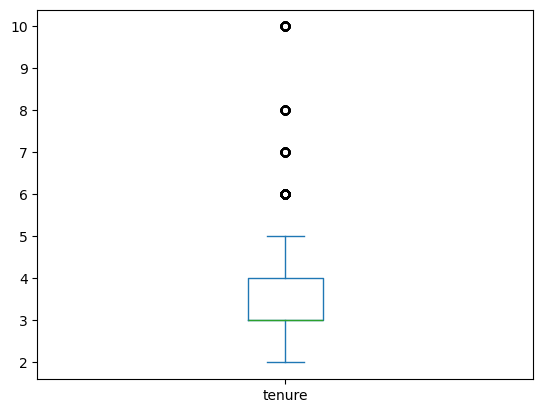

In [31]:
df['tenure'].plot(kind='box')

In [32]:
df['tenure'].describe()

count    11991.000000
mean         3.364857
std          1.330240
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: tenure, dtype: float64

In [33]:
print("data is skew by ",df['tenure'].skew())

data is skew by  1.81657710843447


In [34]:
df[df['tenure']>5]

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
1,0.80,0.86,5,262,6,0,1,0,sales,medium
17,0.78,0.99,4,255,6,0,1,0,sales,low
34,0.84,0.87,4,246,6,0,1,0,hr,low
47,0.57,0.70,3,273,6,0,1,0,support,low
67,0.90,0.98,4,264,6,0,1,0,product_mng,medium
...,...,...,...,...,...,...,...,...,...,...
11994,0.22,0.94,3,193,10,0,0,1,management,high
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high


In [35]:
percentile25th = df['tenure'].quantile(0.25)
percentile75th = df['tenure'].quantile(0.75)

iqr = percentile75th - percentile25th

upperlimit = percentile75th + 1.5 * iqr
lowerlimit = percentile25th - 1.5 * iqr


print("upperlimit :",upperlimit)
print("lowerlimit :",lowerlimit)

outliers = df[ ( df ['tenure'] > upperlimit ) | ( df ['tenure'] < lowerlimit ) ]

print('Number of records with outliers for tenure:', len(outliers))

upperlimit : 5.5
lowerlimit : 1.5
Number of records with outliers for tenure: 824


[]

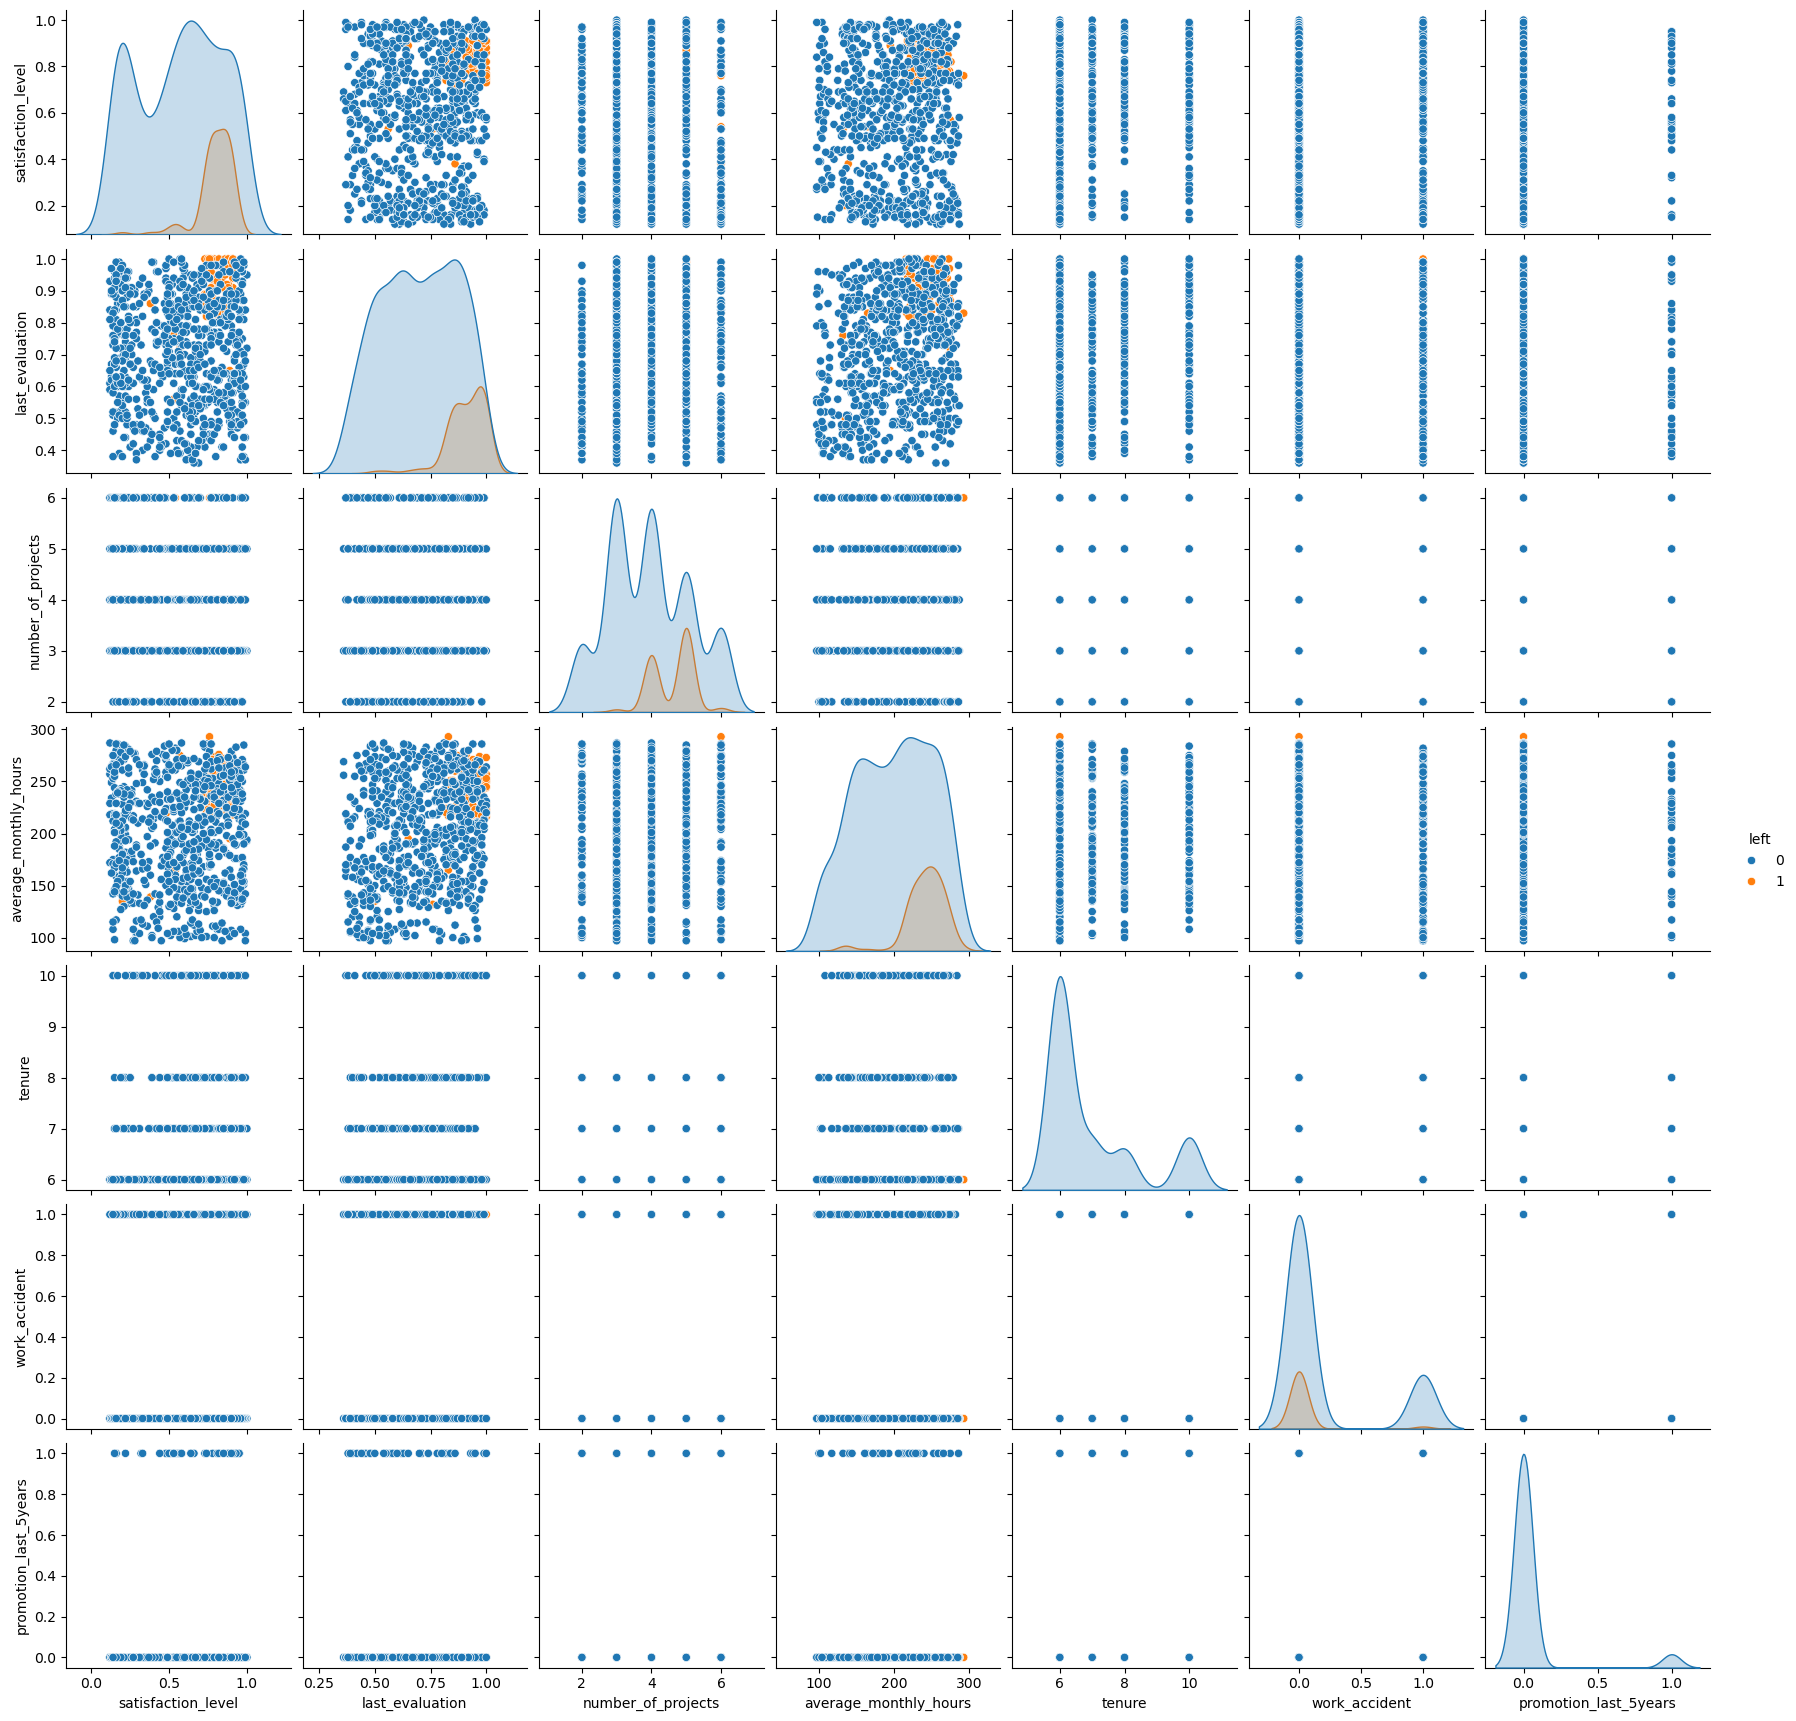

In [36]:
import warnings
warnings.filterwarnings('ignore')
sns.pairplot(outliers, hue ='left')
plt.plot()

* We examined the row and column corresponding to the tenure variable in the pairplot. Although no strong relationships or distinct patterns were observed between tenure and other features, the distribution appears relatively consistent across variables. This suggests that tenure may not strongly influence other features directly, but it still provides useful context for handling potential outliers during preprocessing

In [37]:
df['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

<Axes: ylabel='employee left or not percentage '>

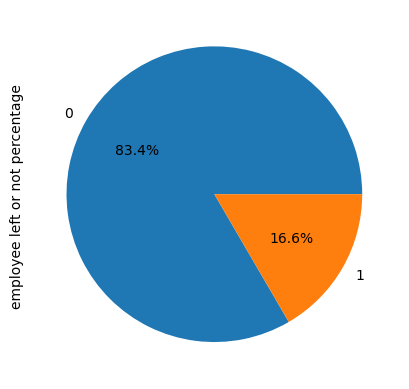

In [38]:
df['left'].value_counts().plot(kind='pie',autopct='%.1f%%',ylabel='employee left or not percentage ')

## The pie chart shows the imbance in the left variable where 83.4% of employees stay and 16.6% are left 

In [39]:
df

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high
11998,0.33,0.65,3,172,10,0,0,1,marketing,high


## Bivariate analysis

In [40]:
pd.crosstab(df['satisfaction_level'],df['left']).T

satisfaction_level,0.09,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,...,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99,1.00
left,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,24,44,55,66,58,59,56,...,163,151,148,143,153,179,150,165,157,100
1,110,203,188,2,1,7,3,1,3,0,...,24,12,0,0,0,0,0,0,0,0


* lower job satisfaction levels are directly linked to a higher poosibility of employee to leaving the company

In [41]:
pd.crosstab(df['number_of_projects'],df['left']).T

number_of_projects,2,3,4,5,6,7
left,,,,,,
0,725,3482,3448,1890,455,0
1,857,38,237,343,371,145


* we are seen that the employees are most likely to leave the company when they are either under engaged (2 projects) or over allocated (6-7 projects) 

In [42]:
pd.crosstab(df['average_monthly_hours'],df['left']).T

average_monthly_hours,96,97,98,99,100,101,102,103,104,105,...,301,302,303,304,305,306,307,308,309,310
left,,,,,,,,,,,,,,,,,,,,,
0,6,13,20,11,17,16,14,14,23,16,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,17,5,5,8,8,8,10,10,7,14


* mostly employees left when there workload exceed the 250+ average working hours

In [43]:
pd.crosstab(df['tenure'],df['left']).T

tenure,2,3,4,5,6,7,8,10
left,,,,,,,,
0,2879,4316,1510,580,433,94,81,107
1,31,874,495,482,109,0,0,0


* the data shows a major quite window between years 3 and 5 with year 5 being the highest risk as nearly half of those employees left the company

In [44]:
pd.crosstab(df['department'],df['left']).T

department,IT,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical
left,,,,,,,,,,
0,818,609,512,488,384,561,576,2689,1509,1854
1,158,85,109,113,52,112,110,550,312,390


* sales and technical are seeing the highest employees are  left

<Axes: xlabel='salary', ylabel='left'>

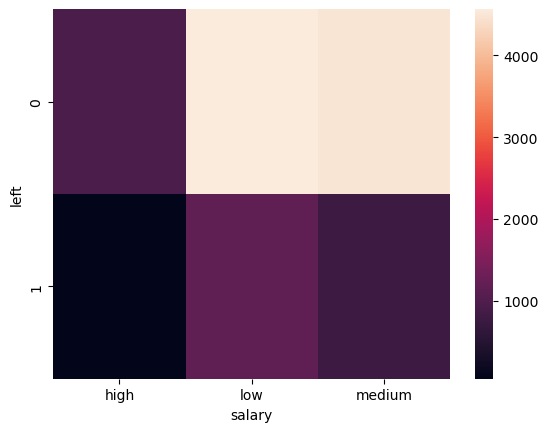

In [45]:
sns.heatmap(pd.crosstab(df['salary'],df['left']).T)

### higher salary employees are almost never leave 

<Axes: xlabel='left', ylabel='work_accident'>

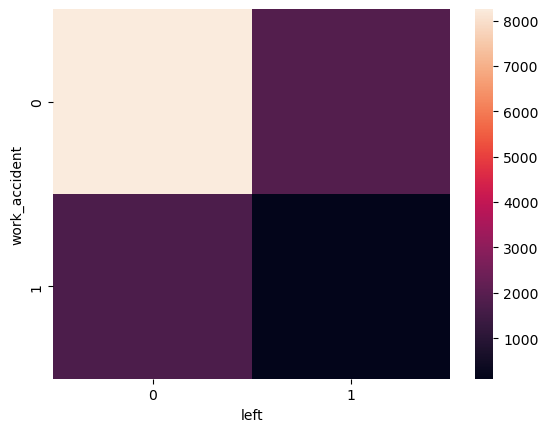

In [46]:
sns.heatmap(pd.crosstab(df['work_accident'],df['left']))

### work accident aren't the major reason of left the company HR doen't need to worry about the safety issues

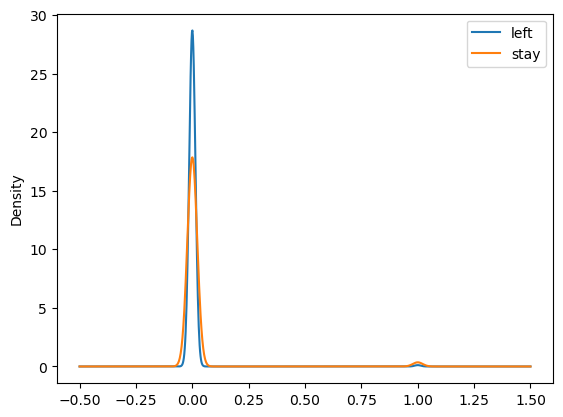

In [47]:
df[df['left']==1]['promotion_last_5years'].plot(kind='kde',label='left')
df[df['left']==0]['promotion_last_5years'].plot(kind='kde',label='stay')

plt.legend()
plt.show()

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_of_projects     11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


In [49]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

<Axes: >

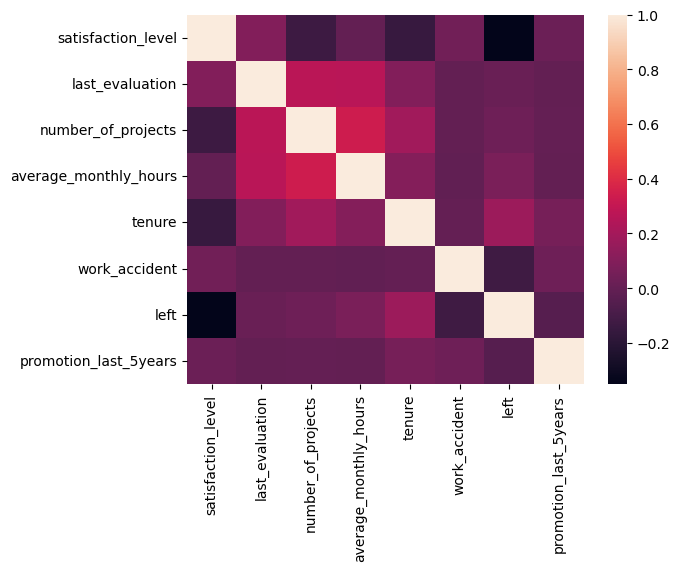

In [50]:
sns.heatmap(df_numeric.corr())

### Job satisfaction is the biggest reason people are quitting while the work accident and promotions are barely have any connection to that

# splitting the data into train and test parts

In [51]:
X=df.drop('left',axis=1)

y=df['left']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=10)

train_data=pd.concat([X_train,y_train],axis=1)

train_data.head()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,promotion_last_5years,department,salary,left
6828,0.34,0.62,4,158,2,0,0,technical,medium,0
4433,0.54,0.81,5,195,4,0,0,management,medium,0
10379,0.61,0.85,4,273,3,0,0,RandD,low,0
11590,0.82,0.65,5,178,7,1,0,sales,medium,0
2195,0.98,0.58,4,136,3,0,0,technical,low,0


In [52]:
X_train

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,promotion_last_5years,department,salary
6828,0.34,0.62,4,158,2,0,0,technical,medium
4433,0.54,0.81,5,195,4,0,0,management,medium
10379,0.61,0.85,4,273,3,0,0,RandD,low
11590,0.82,0.65,5,178,7,1,0,sales,medium
2195,0.98,0.58,4,136,3,0,0,technical,low
...,...,...,...,...,...,...,...,...,...
8105,0.58,0.85,4,162,3,0,0,sales,medium
4790,0.70,0.54,4,150,4,0,0,technical,low
9870,0.96,0.86,2,163,3,0,0,sales,low
11148,0.72,0.53,3,179,3,0,0,support,low


In [53]:
X_test

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,promotion_last_5years,department,salary
11737,0.69,0.66,3,215,6,0,0,sales,high
6619,0.75,0.85,4,181,3,0,0,technical,low
5924,0.74,0.81,5,281,3,1,0,support,low
3135,0.73,0.87,3,142,3,0,0,management,low
11318,0.75,0.94,5,194,4,0,0,technical,low
...,...,...,...,...,...,...,...,...,...
812,0.38,0.49,2,127,3,0,0,support,medium
6674,0.65,0.54,4,260,3,0,0,technical,medium
11117,0.45,0.55,4,206,2,0,0,sales,low
878,0.38,0.47,2,143,3,0,0,technical,low


In [65]:

X_train.to_csv("X_train.csv",index=False)
X_test.to_csv("X_test.csv",index=False)

y_train.to_csv("y_train.csv",index=False)
y_test.to_csv("y_test.csv",index=False)


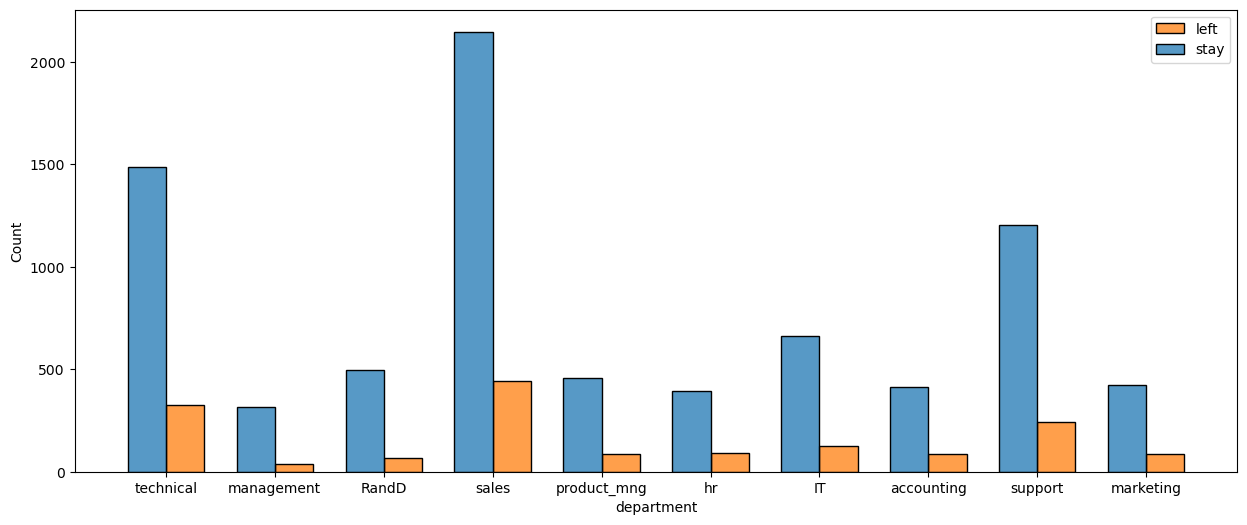

In [54]:
plt.figure(figsize=(15,6))

sns.histplot(
    data=train_data ,
    x='department' ,
    hue='left' ,
    multiple='dodge' ,
    shrink= 0.7
)

plt.legend(labels=['left' , 'stay'])
plt.show()

### sales and technical department have the highest total volume of left and the management and R&D shows the lowest employees left

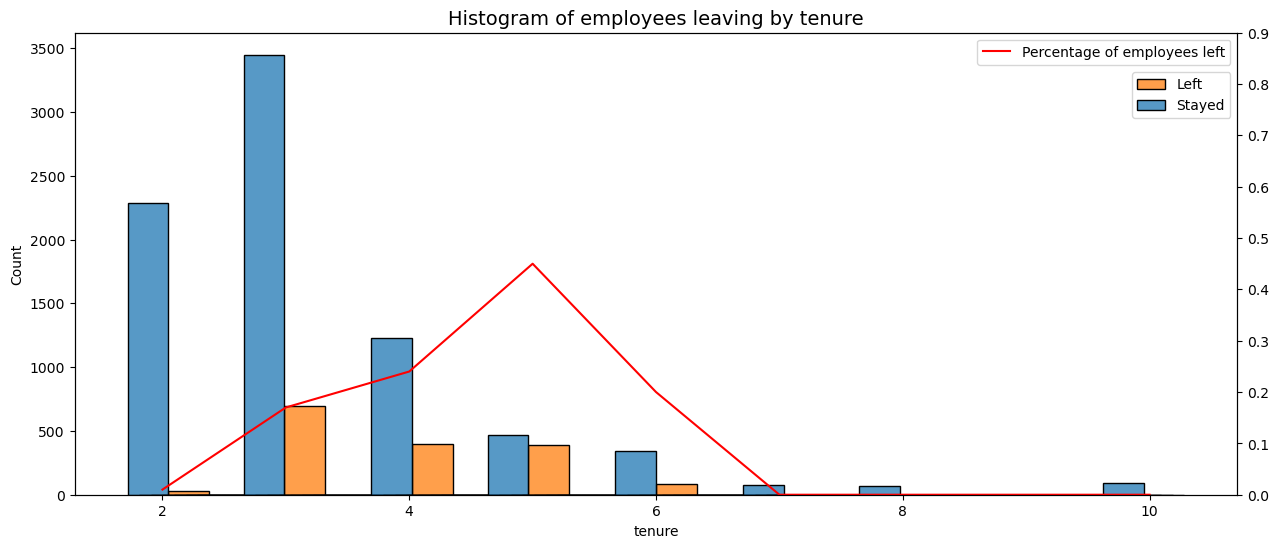

In [55]:
fig,ax1 = plt.subplots(figsize=(15,6))

sns.histplot(
    data=train_data,
    x='tenure' , 
    hue = 'left' , 
    multiple='dodge',
    shrink=7,
    ax=ax1
    
)


ax2=ax1.twinx()

total_each_tenure= train_data['tenure'].value_counts()

total_left_each_tenure = train_data.loc[train_data['left']==1]['tenure'].value_counts()

left_by_tenure=pd.concat([total_each_tenure,total_left_each_tenure],axis=1)

left_by_tenure.columns=['total','left']

left_by_tenure.sort_index(inplace=True)

left_by_tenure.fillna(0,inplace=True)

left_by_tenure['perct']=np.round(left_by_tenure['left']/left_by_tenure['total'],decimals=2)

ax2.plot(left_by_tenure.index,left_by_tenure['perct'],color='red')

ax2.margins(y=0)

ax2.set_yticks(np.arange(0, 1, .10))

ax1.legend(labels = ['Left', 'Stayed'],

loc = "upper right",
           
bbox_to_anchor=(1, 0.93))

ax2.legend(labels = ['Percentage of employees left'])

plt.title('Histogram of employees leaving by tenure', fontsize = 14)

plt.show()


### most of the employees are left between the 3 and 5 years of there tenure while 5th year is most critical point

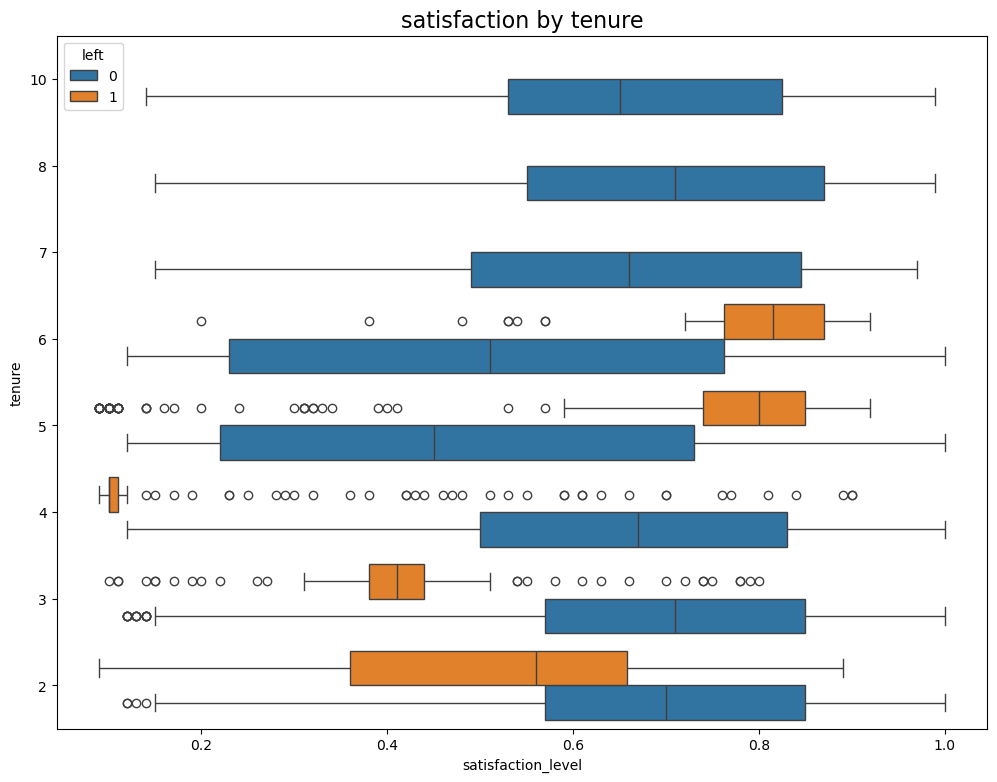

In [56]:
plt.figure(figsize=(12,9))

sns.boxplot(
    data=train_data ,
    x='satisfaction_level' ,
    y='tenure' ,
    hue='left' ,
    dodge=True ,
    orient='h'
).invert_yaxis()

plt.title('satisfaction by tenure',fontsize=16)
plt.show()

### the frustrated high performer employees who leave at year 4 and 5 have extreamly low satisfaction level and those who left at the 2 year of there tenure are actually have higher satisfaction than who stay

In [57]:
print("Column 3 'perct' gives the percentage (in decimal) of total employees who left the company for each tenure.")
left_by_tenure

Column 3 'perct' gives the percentage (in decimal) of total employees who left the company for each tenure.


,total,left,perct
tenure,,,
2,2314,26.0,0.01
3,4148,699.0,0.17
4,1620,395.0,0.24
5,854,387.0,0.45
6,426,86.0,0.20
7,74,0.0,0.00
8,65,0.0,0.00
10,91,0.0,0.00


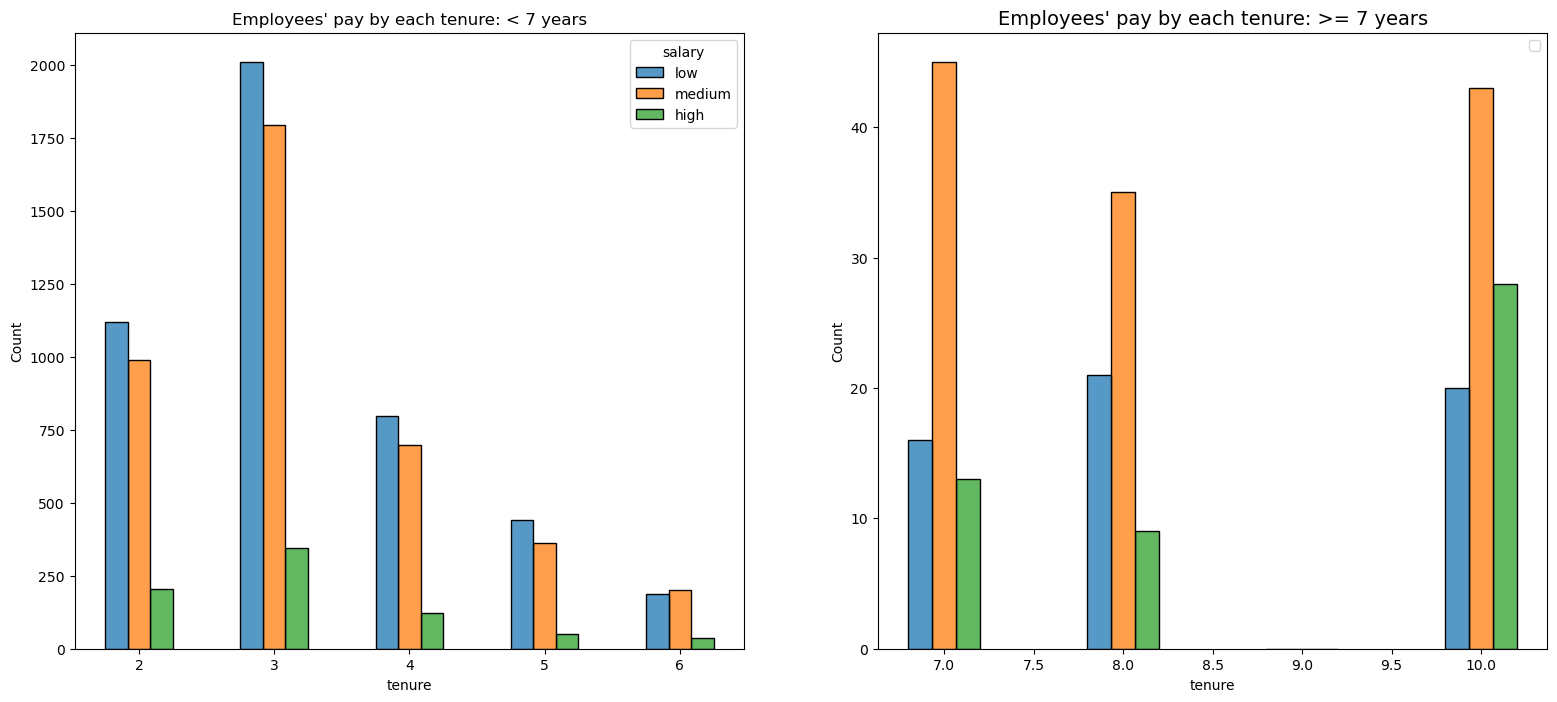

In [58]:
fig, ax = plt.subplots(1, 2, figsize = (19, 8))

tenure_short = train_data[train_data['tenure'] < 7]

tenure_long = train_data[train_data['tenure'] > 6]

sns.histplot(
    data=tenure_short, 
    x='tenure', hue='salary', 
    discrete=1,hue_order=['low', 'medium', 'high'], 
    multiple='dodge', 
    shrink=.5, 
    ax=ax[0])
    
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

sns.histplot(
    data=tenure_long, 
    x='tenure', hue='salary', 
    discrete=1,hue_order=['low', 'medium', 'high'], 
    multiple='dodge', 
    shrink=.4, 
    ax=ax[1]
)

ax[1].legend(loc = None)

ax[0].set_title("Employees' pay by each tenure: < 7 years")

ax[1].set_title("Employees' pay by each tenure: >= 7 years", fontsize =14)

plt.show()


### Interpretation
* the early career drop in year 2 and 3 the low(blue bar) salary category by far the most populated but the total employee count is collapse by over 80% as tenure approaches year 6
* the pay transition for the small groups of who reaches the 7- 10 year the hierarchy flips medium salary (orange) becomes the most common and the proportion of higest earner(green) incereases significantly 
* tenure 10 :-  by  year 10 there are few employee remaining (under 30) but non of them are still in the low salary bracket

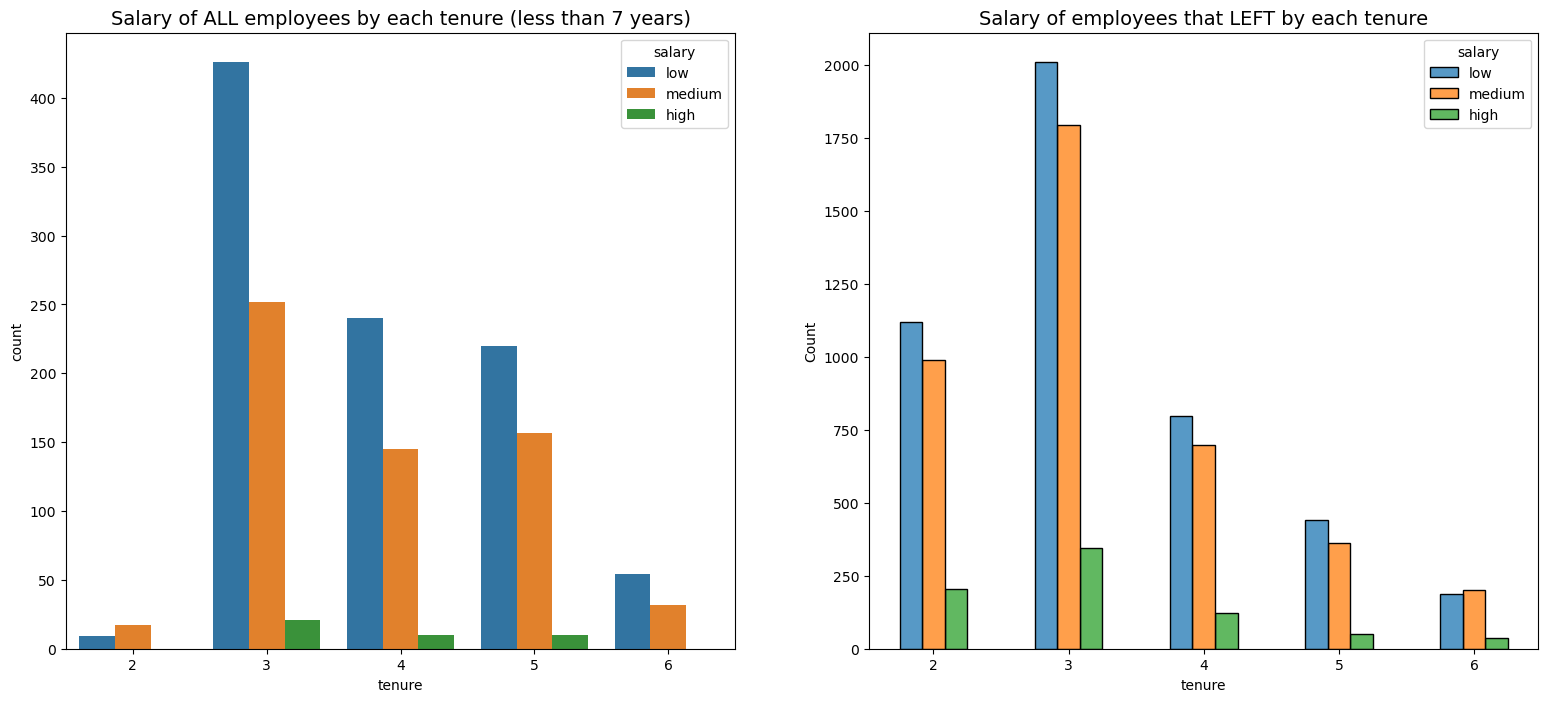

In [59]:
salary_of_left=train_data[train_data['left']==1][['tenure','salary']].value_counts().reset_index()

fig,ax=plt.subplots(1,2,figsize=(19,8))

sns.barplot(
    data=salary_of_left ,
    x='tenure' ,
    y='count' ,
    hue='salary' ,
    hue_order=['low','medium','high'] ,
    ax=ax[0]
)

tenure_short=train_data[train_data['tenure']<7]

sns.histplot(data=tenure_short,
            x='tenure',
            hue='salary',
            discrete=1,
            hue_order=['low', 'medium', 'high'],
            multiple='dodge',
            shrink=0.5,
            ax=ax[1]
)

ax[0].set_title('Salary of ALL employees by each tenure (less than 7 years)', fontsize='14')

plt.title('Salary of employees that LEFT by each tenure', fontsize = 14)

plt.show()




### low salary is primary driver :- 
* the vast  majority of employee who left are in low salary bracket while high earners almost never quit
### the year 3 danger zone :-
* turnover peaks dramatically at the 3rd year of tenure which is the most ciritical point for losing staff across all salary levels

In [60]:
df

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high
11998,0.33,0.65,3,172,10,0,0,1,marketing,high


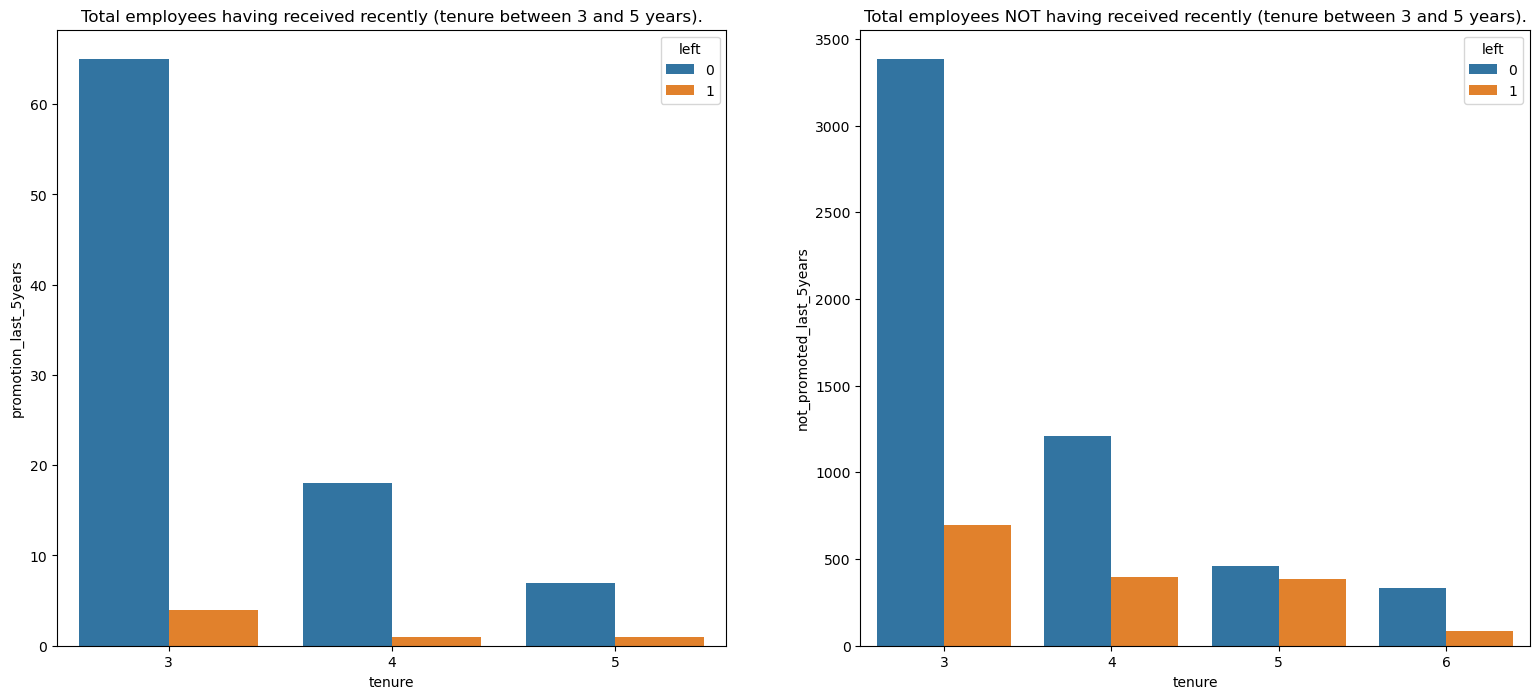

In [61]:
fig,ax=plt.subplots(1,2,figsize=(19,8))

received_promotion=train_data[['tenure','left','promotion_last_5years']].groupby(['left','tenure']).sum().reset_index()

received_promotion=received_promotion.loc[(received_promotion['tenure']>=3) & (received_promotion['tenure']<6)]

sns.barplot(
    data=received_promotion ,
    x='tenure' ,
    y='promotion_last_5years' ,
    hue='left' ,
    ax=ax[0]
)

not_received_promotion=train_data[['tenure','left','promotion_last_5years']]

not_received_promotion['not_promoted_last_5years'] = (not_received_promotion['promotion_last_5years'] == 0).astype(int)

not_received_promotion.drop(['promotion_last_5years'], axis =1, inplace= True)

not_received_promotion = not_received_promotion.groupby(['tenure', 'left']).sum().reset_index()

not_received_promotion = not_received_promotion.loc[(not_received_promotion['tenure'] >= 3) & (not_received_promotion['tenure'] <= 6)]

sns.barplot(
data = not_received_promotion,
x = 'tenure',
y = 'not_promoted_last_5years',
hue = 'left',
ax = ax[1]
)
ax[0].set_title('Total employees having received recently (tenure between 3 and 5 years).')

ax[1].set_title('Total employees NOT having received recently (tenure between 3 and 5 years).')
plt.show()


### Promotions are a Retention shield :- 
* almost less than 10 employee left the who reveived a promotion in the last 5 year left the company
*  the vast majority of turnover happen among those not promoted with most critical volume of departures occurring at the 3-year mark

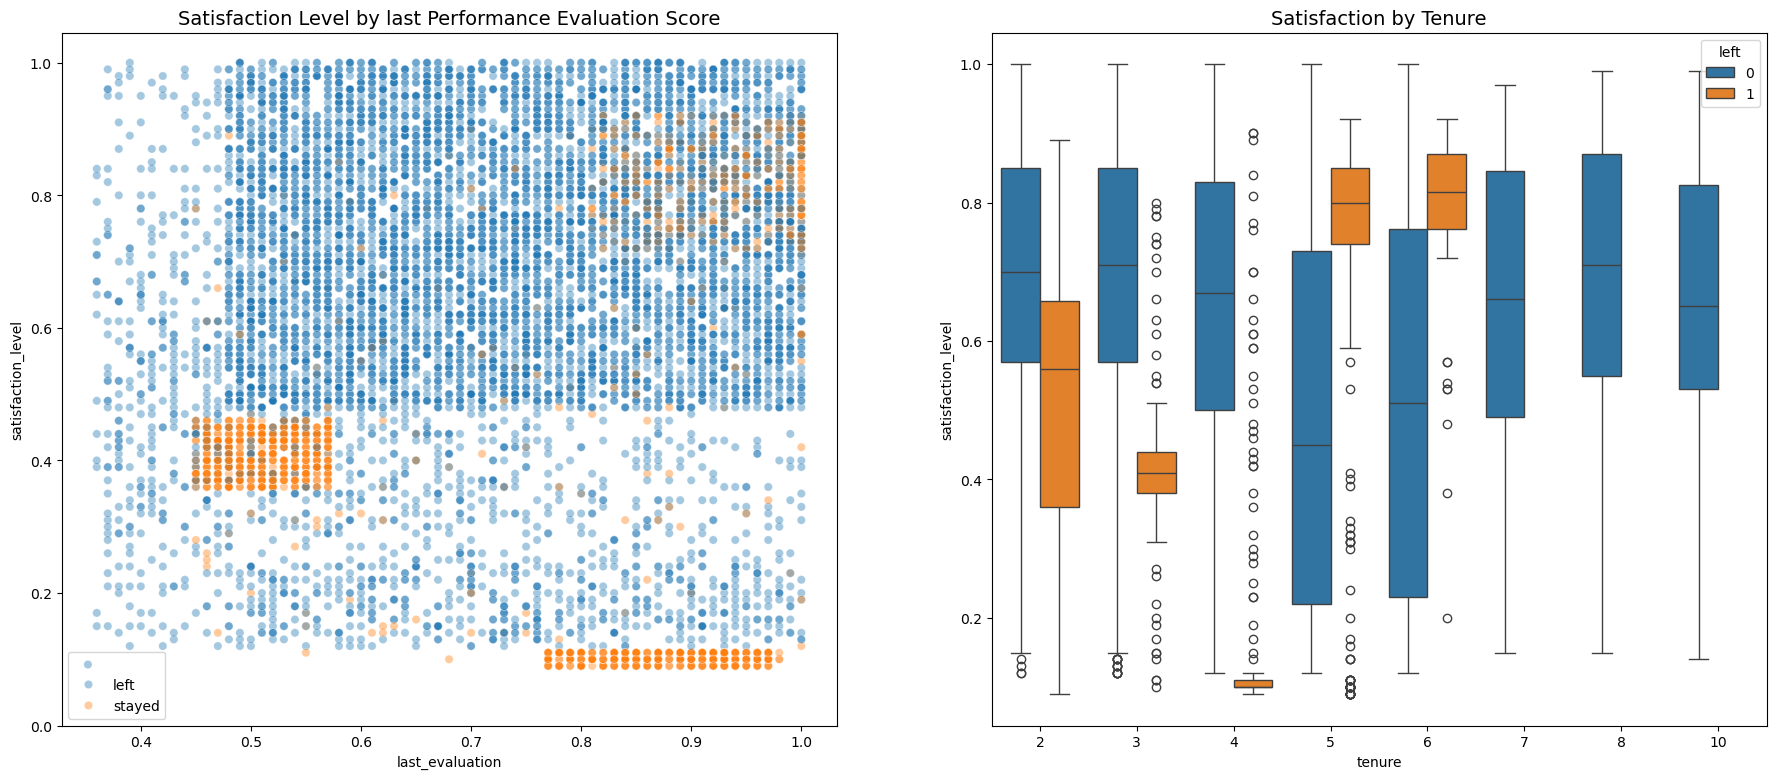

In [62]:
fig, ax = plt.subplots(1, 2, figsize = (22, 9))

sns.scatterplot(
    data = train_data,
    y = 'satisfaction_level',
    x = 'last_evaluation',
    hue = 'left',
    alpha = 0.4, ax = ax[0]
)

ax[0].set_title('Satisfaction Level by last Performance Evaluation Score', fontsize = 14)

ax[0].legend(labels = [None, 'left', 'stayed'])

ax[0].set_yticks(np.arange(0, 1.01, 0.2))

sns.boxplot(
    data = train_data,
    y = 'satisfaction_level',
    x = 'tenure',
    hue = 'left',
    dodge = True,
    ax = ax[1]
)

ax[1].set_title('Satisfaction by Tenure', fontsize = 14)

plt.show()


### the frustrated high performer :-
* the scatter plot reveals a major cluster of employees who left (orange)  despite having very high performance evaluation score (>0.8) because their satisfaction was extremely low(<0.15)
### the 4-year satisfaction crash :-
* the box plot shows that satisfaction for those who leave (orange) plummented critically at tenure year 4 while those who stay maintained high consistent satisfaction throughout their entire tenure

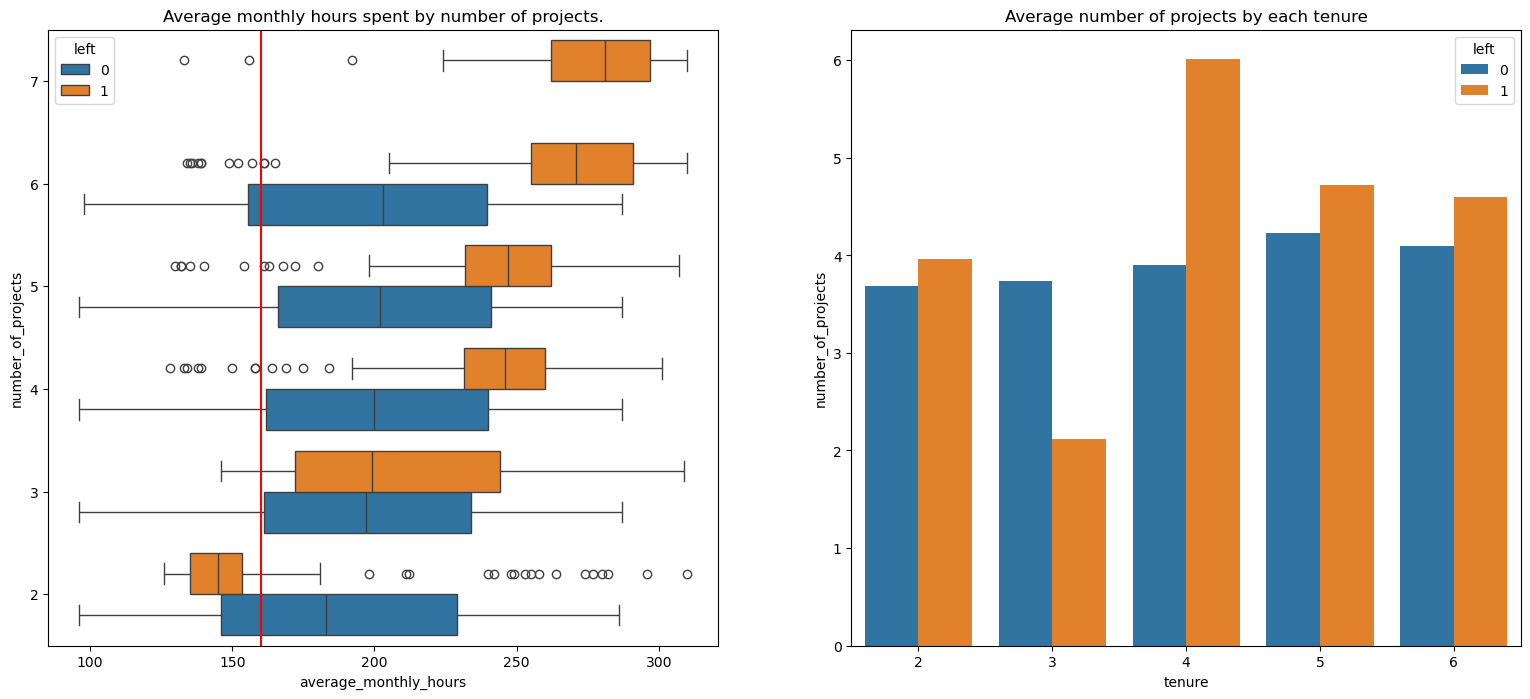

In [63]:
fig, ax = plt.subplots(1, 2, figsize = (19, 8))

sns.boxplot(
    data = train_data,
    y = 'number_of_projects',
    x = 'average_monthly_hours',
    hue = 'left',
    dodge = True,
    orient = 'h',
    ax = ax[0]
).invert_yaxis()

ax[0].axvline(
    x = 160,
    color = 'red'
)

sns.barplot(
    data = train_data.groupby(['tenure', 'left']).aggregate({'number_of_projects': 'mean'}).reset_index(),
    y = 'number_of_projects',
    x = 'tenure',
    hue = 'left',
    ax = ax[1]
)

ax[1].set_xlim([-0.5, 4.5])

ax[0].set_title('Average monthly hours spent by number of projects.')

ax[1].set_title('Average number of projects by each tenure')

plt.show()


### the overwork "Burnout" trap :-
* Employees who leave (orange) are characterized by extreme overloading - frequently working 250-300+ monthly hours on 6-7 projects whereas those who stay (blue) maintain a much more sustainable workload.
### project inequity at mid tenure :-
* at the critical 4-year mark those who leave are assigned significantly more projects on average than their peers who stay indicating that excessive project volume is a direct catalyst for mid tenure turnover

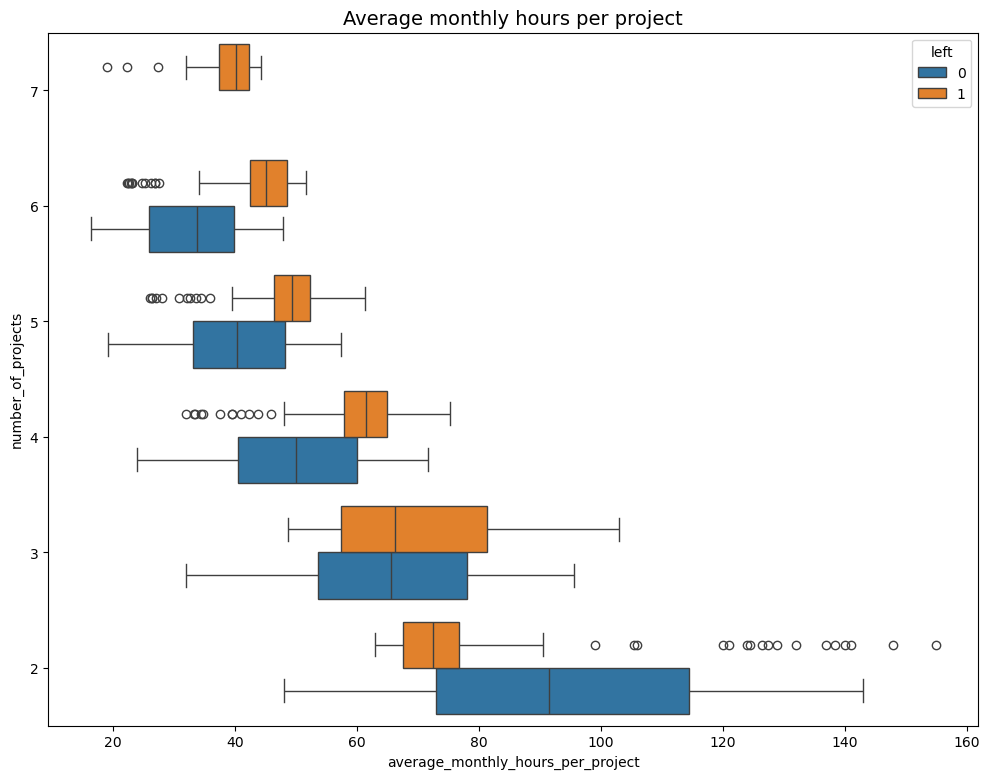

In [64]:

plt.figure(figsize = (12, 9))

avg_hours = train_data[["left", "tenure", "average_monthly_hours", "number_of_projects"]]

avg_hours["average_monthly_hours_per_project"] = avg_hours['average_monthly_hours'] / avg_hours['number_of_projects']

sns.boxplot(
    data = avg_hours,
    y = 'number_of_projects',
    x = 'average_monthly_hours_per_project',
    hue = 'left',
    dodge = True,
    orient = 'h'
).invert_yaxis()

plt.title('Average monthly hours per project', fontsize = 14)

plt.show()

* the employee who left were either not given enough work(2 projects) or were pushed way too hard with a 7-project load.